In [3]:
import pandas as pd 

matches = pd.read_csv("../data/wc_teams/results.csv")
rankings = pd.read_csv("../data/rankings/fifa_ranking-2024-06-20.csv")
train = pd.read_csv("../data/results/train.csv")
rankings.head()  #this represents the FIFA rankings which will help model to understand the strength of the teams.



,rank,country_full,country_abrv,total_points,previous_points,rank_change,confederation,rank_date
0,140.0,Brunei Darussalam,BRU,2.0,0.0,140,AFC,1992-12-31
1,33.0,Portugal,POR,38.0,0.0,33,UEFA,1992-12-31
2,32.0,Zambia,ZAM,38.0,0.0,32,CAF,1992-12-31
3,31.0,Greece,GRE,38.0,0.0,31,UEFA,1992-12-31
4,30.0,Algeria,ALG,39.0,0.0,30,CAF,1992-12-31


In [4]:
train.head() # this represents the training data which will be used to train the model and it helps in understanding how a teams performance in the past mathces

,version,team,continent,is_host,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,losses_last_4y,draws_last_4y,world_cup_titles_before,...,world_cup_participations_before,groups_passed_before,round16_before,quarterfinals_before,semifinals_before,finals_before,winner,finalist,semi_finalist,quarter_finalist
0,2006,Angola,Africa,0,61,49,19,13,14,0,...,0,0,0,0,0,0,0,0,0,0
1,2006,Argentina,South America,0,97,55,31,10,10,2,...,13,10,5,6,4,4,0,0,0,1
2,2006,Australia,Oceania,0,101,34,23,8,5,0,...,1,0,0,0,0,0,0,0,0,0
3,2006,Brazil,South America,0,117,47,30,9,17,5,...,17,15,7,11,9,6,0,0,0,1
4,2006,Costa Rica,North America,0,89,84,26,25,11,0,...,2,1,1,0,0,0,0,0,0,0


In [5]:
matches.head() # this helps in understading who played agains who and what was the result of the match and it also helps in understanding the performance of the teams in the past matches


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [14]:
print("matches shape:", matches.shape)
print("rankings shape:", rankings.shape) 
print("train shape:", train.shape)

matches shape: (49477, 9)
rankings shape: (67472, 8)
train shape: (192, 24)


In [18]:
print(matches.columns.tolist())
print(rankings.columns.tolist())
print(train.columns.tolist())

['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']
['rank', 'country_full', 'country_abrv', 'total_points', 'previous_points', 'rank_change', 'confederation', 'rank_date']
['version', 'team', 'continent', 'is_host', 'goals_scored_last_4y', 'goals_received_last_4y', 'wins_last_4y', 'losses_last_4y', 'draws_last_4y', 'world_cup_titles_before', 'squad_total_market_value_eur', 'fifa_rank_pre_tournament', 'fifa_points_pre_tournament', 'squad_avg_age', 'world_cup_participations_before', 'groups_passed_before', 'round16_before', 'quarterfinals_before', 'semifinals_before', 'finals_before', 'winner', 'finalist', 'semi_finalist', 'quarter_finalist']


In [19]:
print(matches.isnull().sum())
print(rankings.isnull().sum())
print(train.isnull().sum())

date           0
home_team      0
away_team      0
home_score    70
away_score    70
tournament     0
city           0
country        0
neutral        0
dtype: int64
rank               9
country_full       0
country_abrv       0
total_points       0
previous_points    0
rank_change        0
confederation      0
rank_date          0
dtype: int64
version                             0
team                                0
continent                           0
is_host                             0
goals_scored_last_4y                0
goals_received_last_4y              0
wins_last_4y                        0
losses_last_4y                      0
draws_last_4y                       0
world_cup_titles_before             0
squad_total_market_value_eur       32
fifa_rank_pre_tournament            0
fifa_points_pre_tournament          0
squad_avg_age                       0
world_cup_participations_before     0
groups_passed_before                0
round16_before                      0
quarter

In [22]:
print(matches.info())
print(rankings.info())
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49477 entries, 0 to 49476
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49477 non-null  object 
 1   home_team   49477 non-null  object 
 2   away_team   49477 non-null  object 
 3   home_score  49407 non-null  float64
 4   away_score  49407 non-null  float64
 5   tournament  49477 non-null  object 
 6   city        49477 non-null  object 
 7   country     49477 non-null  object 
 8   neutral     49477 non-null  bool   
dtypes: bool(1), float64(2), object(6)
memory usage: 3.1+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67472 entries, 0 to 67471
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rank             67463 non-null  float64
 1   country_full     67472 non-null  object 
 2   country_abrv     67472 non-null  object 
 3   total_points     67472 non-null 

In [6]:
def get_result(row):
    if row['home_score'] > row['away_score']:
        return "Home Win"
    elif row["home_score"] < row['away_score']:
        return "Away Win"
    else:
        return "Draw"

matches_clean = matches.dropna(subset=['home_score', 'away_score'])

matches_clean["result"] = matches_clean.apply(get_result, axis=1)
matches_clean["result"].value_counts()

C:\Users\HP\AppData\Local\Temp\ipykernel_22632\227102170.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matches_clean["result"] = matches_clean.apply(get_result, axis=1)


result
Home Win    24214
Away Win    13960
Draw        11233
Name: count, dtype: int64

In [20]:
all_teams = pd.concat([matches['home_team'],matches['away_team']])
all_teams.value_counts().head(20)

Sweden         1104
England        1093
Argentina      1072
Brazil         1062
Germany        1034
South Korea    1010
Mexico         1006
Hungary        1006
Uruguay         973
France          938
Italy           893
Poland          892
Switzerland     887
Netherlands     882
Norway          875
Denmark         874
Thailand        865
Austria         863
Belgium         856
Scotland        854
Name: count, dtype: int64

In [21]:
all_teams.nunique()

336

In [22]:
sorted(all_teams.unique())[:50]

['Abkhazia',
 'Afghanistan',
 'Albania',
 'Alderney',
 'Algeria',
 'Ambazonia',
 'American Samoa',
 'Andalusia',
 'Andorra',
 'Angola',
 'Anguilla',
 'Antigua and Barbuda',
 'Arameans Suryoye',
 'Argentina',
 'Armenia',
 'Artsakh',
 'Aruba',
 'Asturias',
 'Australia',
 'Austria',
 'Aymara',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barawa',
 'Barbados',
 'Basque Country',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Biafra',
 'Bolivia',
 'Bonaire',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'British Virgin Islands',
 'Brittany',
 'Brunei',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Canary Islands']

In [7]:
former_names = pd.read_csv("../data/wc_teams/former_names.csv")
former_names.head(20)

,current,former,start_date,end_date
0,Benin,Dahomey,1959-11-08,1975-11-30
1,Burkina Faso,Upper Volta,1960-04-14,1984-08-04
2,Curaçao,Netherlands Antilles,1957-03-03,2010-10-10
3,Czechoslovakia,Bohemia,1903-04-05,1919-01-01
4,Czechoslovakia,Bohemia and Moravia,1939-01-01,1945-05-01
5,Czechoslovakia,Representation of Czechs and Slovaks,1993-03-24,1993-11-17
6,DR Congo,Belgian Congo,1948-05-25,1956-01-02
7,DR Congo,Congo-Léopoldville,1963-04-12,1964-07-19
8,DR Congo,Congo-Kinshasa,1965-01-09,1970-11-24
9,DR Congo,Zaïre,1971-01-10,1997-04-27


In [8]:
print("Earliest Match")
print(matches_clean['date'].min())

Earliest Match
1872-11-30


In [17]:
print("Latest Match")
print(matches_clean['date'].max())

Latest Match
2026-06-11


In [9]:
matches_clean["tournament"].value_counts().head(20)

tournament
Friendly                                18388
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                            966
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations League                       658
CECAFA Cup                                620
CFU Caribbean Cup qualification           606
Merdeka Tournament                        599
British Home Championship                 523
CONCACAF Nations League                   422
AFC Asian Cup                             421
Gold Cup                                  420
Gulf Cup                                  410
Island Games                              394
UEFA Euro                                 388
Asian Games                               368
Name: count, dtype: int64

In [10]:
print("Average Home Goals:")
print(matches_clean["home_score"].mean())

print("\nAverage Away Goals:")
print(matches_clean["away_score"].mean())

Average Home Goals:
1.757261116845791

Average Away Goals:
1.1818973020017407


In [11]:
print("\nHighest Home Score:")
print(matches_clean["home_score"].max())

print("\nHighest Away Score:")
print(matches_clean["away_score"].max())


Highest Home Score:
31.0

Highest Away Score:
21.0


In [12]:
matches_clean[
    matches_clean["home_score"] == matches_clean["home_score"].max()
][["date","home_team","away_team","home_score","away_score","tournament"]]

,date,home_team,away_team,home_score,away_score,tournament
25425,2001-04-11,Australia,American Samoa,31.0,0.0,FIFA World Cup qualification


In [13]:
matches_clean[
    matches_clean["away_score"] == matches_clean["away_score"].max()
][["date","home_team","away_team","home_score","away_score","tournament"]]

,date,home_team,away_team,home_score,away_score,tournament
29045,2005-03-11,Guam,North Korea,0.0,21.0,EAFF Championship


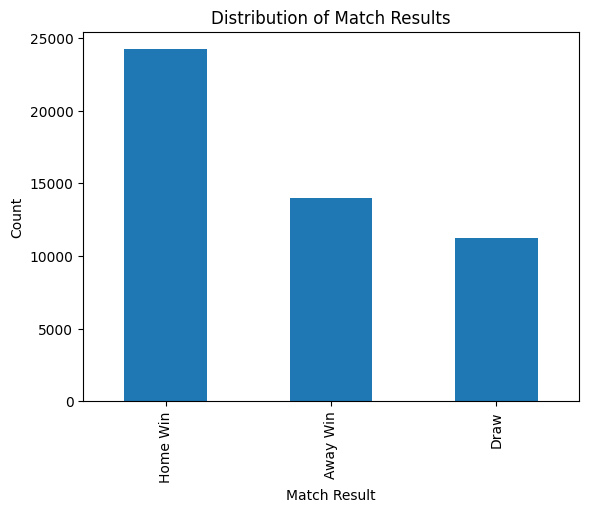

In [23]:
import matplotlib.pyplot as plt

matches_clean["result"].value_counts().plot(kind="bar")
plt.title("Distribution of Match Results")
plt.xlabel("Match Result")  
plt.ylabel("Count")
plt.show()

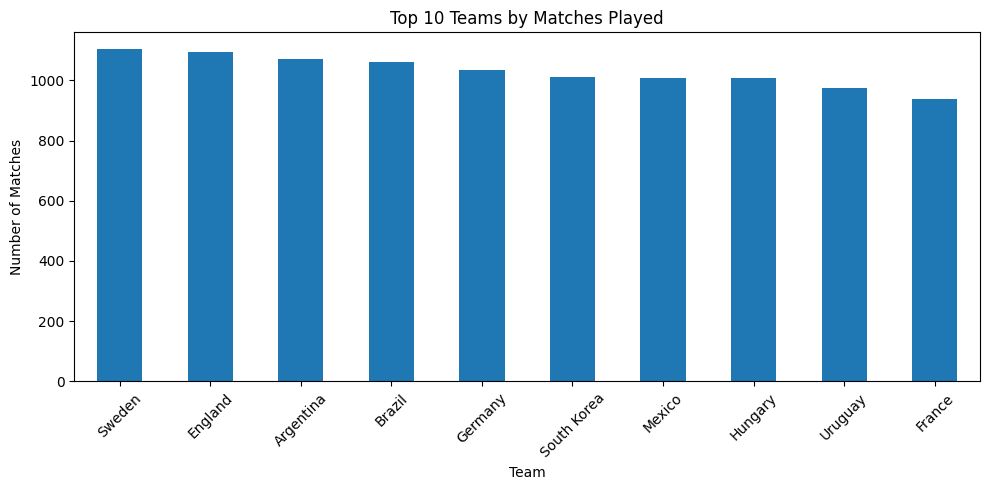

In [24]:
import matplotlib.pyplot as plt
top_teams = all_teams.value_counts().head(10)

plt.figure(figsize=(10,5))
top_teams.plot(kind="bar")

plt.title("Top 10 Teams by Matches Played")
plt.xlabel("Team")
plt.ylabel("Number of Matches")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [16]:
matches_clean["date"] = pd.to_datetime(matches_clean["date"])
matches_clean["date"].dtype

C:\Users\HP\AppData\Local\Temp\ipykernel_22632\2821300505.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matches_clean["date"] = pd.to_datetime(matches_clean["date"])


dtype('<M8[ns]')

In [15]:
matches_clean["year"] = matches_clean["date"].dt.year
matches_clean[["date","year"]].head()

C:\Users\HP\AppData\Local\Temp\ipykernel_22632\4209116682.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matches_clean["year"] = matches_clean["date"].dt.year


,date,year
0,1872-11-30,1872
1,1873-03-08,1873
2,1874-03-07,1874
3,1875-03-06,1875
4,1876-03-04,1876


In [23]:
match_teams = set(all_teams.unique())
rankings_teams = set(rankings["country_full"].unique())
missing_teams = match_teams - rankings_teams
print("Number of missing teams")
print(len(missing_teams))

Number of missing teams
142


In [24]:
list(missing_teams)[:30]

['Taiwan',
 'Czech Republic',
 'Saint Pierre and Miquelon',
 'Gotland',
 'Frøya',
 'Republic of St. Pauli',
 'Zanzibar',
 'Luhansk PR',
 'Canary Islands',
 'Shetland',
 'East Turkestan',
 'Kurdistan',
 'Åland Islands',
 'Basque Country',
 'Iraqi Kurdistan',
 'Brittany',
 'Niue',
 'Western Armenia',
 'Ryūkyū',
 'North Korea',
 'Surrey',
 'Kiribati',
 'Artsakh',
 'Maule Sur',
 'Ivory Coast',
 'Seborga',
 'Chagos Islands',
 'South Yemen',
 'South Ossetia',
 'Occitania']

In [25]:
ranking_teams = set(rankings["country_full"].unique())

for team in sorted(missing_teams):
    if "Korean" in team:
        print(team)

for team in sorted(ranking_teams):
    if "Korea" in team:
        print(team)

United Koreans in Japan
Korea DPR
Korea Republic


In [26]:
train.columns.tolist()

['version',
 'team',
 'continent',
 'is_host',
 'goals_scored_last_4y',
 'goals_received_last_4y',
 'wins_last_4y',
 'losses_last_4y',
 'draws_last_4y',
 'world_cup_titles_before',
 'squad_total_market_value_eur',
 'fifa_rank_pre_tournament',
 'fifa_points_pre_tournament',
 'squad_avg_age',
 'world_cup_participations_before',
 'groups_passed_before',
 'round16_before',
 'quarterfinals_before',
 'semifinals_before',
 'finals_before',
 'winner',
 'finalist',
 'semi_finalist',
 'quarter_finalist']

In [27]:
train["winner"].value_counts()

winner
0    186
1      6
Name: count, dtype: int64

In [28]:
rankings["rank_date"] = pd.to_datetime(rankings["rank_date"])
print(rankings["rank_date"].min())
print(rankings["rank_date"].max())

1992-12-31 00:00:00
2024-06-20 00:00:00


In [29]:
modern_matches = matches_clean[matches_clean["year"]>=1992]
print("original matches: ", len(matches_clean))
print("modern matches: ", len(modern_matches))

original matches:  49407
modern matches:  31299


In [30]:
rankings[rankings["country_full"] == "Argentina"].head()

,rank,country_full,country_abrv,total_points,previous_points,rank_change,confederation,rank_date
64,10.0,Argentina,ARG,51.0,0.0,10,CONMEBOL,1992-12-31
274,5.0,Argentina,ARG,56.0,51.0,-5,CONMEBOL,1993-08-08
375,12.0,Argentina,ARG,55.0,56.0,7,CONMEBOL,1993-09-23
549,9.0,Argentina,ARG,55.0,55.0,-3,CONMEBOL,1993-10-22
710,9.0,Argentina,ARG,55.0,55.0,0,CONMEBOL,1993-11-19


In [31]:
rankings["country_full"].value_counts().head(20)

country_full
Brunei Darussalam    333
Botswana             333
Libya                333
Solomon Islands      333
Cabo Verde           333
Mauritania           333
Portugal             333
Estonia              333
Slovenia             333
Haiti                333
Ukraine              333
Guyana               333
Benin                333
San Marino           333
Venezuela            333
South Africa         333
Tahiti               333
Puerto Rico          333
Togo                 333
Canada               333
Name: count, dtype: int64

In [32]:
print("Brazil in matches:",
      "Brazil" in match_teams)

print("Brazil in rankings:",
      "Brazil" in ranking_teams)

Brazil in matches: True
Brazil in rankings: True


In [33]:
modern_matches[
    modern_matches["home_team"] == "Brazil"
][["date","home_team","away_team"]].head()

,date,home_team,away_team
18154,1992-02-26,Brazil,United States
18194,1992-04-15,Brazil,Finland
18382,1992-07-31,Brazil,Mexico
18498,1992-09-23,Brazil,Costa Rica
18656,1992-11-25,Brazil,Uruguay


In [34]:
first_ranking_date = rankings["rank_date"].min()

early_matches = modern_matches[
    modern_matches["date"] < first_ranking_date
]

print("Matches before first ranking:")
print(len(early_matches))

Matches before first ranking:
600


In [35]:
ranking_start = rankings["rank_date"].min()

matches_ranked = modern_matches[modern_matches["date"] >= ranking_start].copy()

print("Matches with rankings available:")
print(len(matches_ranked))

Matches with rankings available:
30699


In [36]:
matches_ranked[["date","home_team","away_team"]].head(1)

,date,home_team,away_team
18708,1993-01-01,Ghana,Mali


In [37]:
rankings[rankings["country_full"] == "Ghana"].head(10)

,rank,country_full,country_abrv,total_points,previous_points,rank_change,confederation,rank_date
36,39.0,Ghana,GHA,34.0,0.0,39,CAF,1992-12-31
318,48.0,Ghana,GHA,34.0,34.0,9,CAF,1993-08-08
367,42.0,Ghana,GHA,37.0,34.0,-6,CAF,1993-09-23
560,40.0,Ghana,GHA,37.0,37.0,-2,CAF,1993-10-22
704,41.0,Ghana,GHA,37.0,37.0,1,CAF,1993-11-19
972,37.0,Ghana,GHA,40.0,37.0,-4,CAF,1993-12-23
1061,35.0,Ghana,GHA,39.0,40.0,-2,CAF,1994-02-15
1254,31.0,Ghana,GHA,41.0,39.0,-4,CAF,1994-03-15
1482,29.0,Ghana,GHA,44.0,41.0,-2,CAF,1994-04-19
1582,28.0,Ghana,GHA,44.0,44.0,-1,CAF,1994-05-17


In [38]:
rankings[
    rankings["country_full"] == "Mali"
].head(10)

,rank,country_full,country_abrv,total_points,previous_points,rank_change,confederation,rank_date
123,69.0,Mali,MLI,22.0,0.0,69,CAF,1992-12-31
301,74.0,Mali,MLI,24.0,22.0,5,CAF,1993-08-08
359,70.0,Mali,MLI,27.0,24.0,-4,CAF,1993-09-23
496,73.0,Mali,MLI,25.0,27.0,3,CAF,1993-10-22
690,75.0,Mali,MLI,23.0,25.0,2,CAF,1993-11-19
950,70.0,Mali,MLI,25.0,23.0,-5,CAF,1993-12-23
1140,61.0,Mali,MLI,29.0,25.0,-9,CAF,1994-02-15
1324,57.0,Mali,MLI,31.0,29.0,-4,CAF,1994-03-15
1421,48.0,Mali,MLI,34.0,31.0,-9,CAF,1994-04-19
1654,48.0,Mali,MLI,34.0,34.0,0,CAF,1994-05-17


In [39]:
home_rank = 39
away_rank = 69

rank_difference = away_rank - home_rank

print("Rank Difference:", rank_difference)

Rank Difference: 30


In [40]:
sample_match = matches_ranked.iloc[0]
print(sample_match["date"])
print(sample_match["home_team"])
print(sample_match["away_team"])

1993-01-01 00:00:00
Ghana
Mali


In [41]:
ghana_before_match = rankings[(rankings["country_full"] =="Ghana") & (rankings["rank_date"] <= sample_match["date"])]
ghana_before_match.tail()

,rank,country_full,country_abrv,total_points,previous_points,rank_change,confederation,rank_date
36,39.0,Ghana,GHA,34.0,0.0,39,CAF,1992-12-31


In [43]:
def get_team_rank(team_name, match_date):

    team_rankings = rankings[
        (rankings["country_full"] == team_name)
        &
        (rankings["rank_date"] <= match_date)
    ]

    if len(team_rankings) == 0:
        return None

    latest_rank = team_rankings.sort_values(
        "rank_date"
    ).iloc[-1]

    return latest_rank["rank"]

print(
    get_team_rank(
        sample_match["home_team"],
        sample_match["date"]
    )
)

print(
    get_team_rank(
        sample_match["away_team"],
        sample_match["date"]
    )
)

39.0
69.0


In [44]:
home_rank = get_team_rank(
    sample_match["home_team"],
    sample_match["date"]
)

away_rank = get_team_rank(
    sample_match["away_team"],
    sample_match["date"]
)

rank_difference = away_rank - home_rank

print("Home Rank:", home_rank)
print("Away Rank:", away_rank)
print("Rank Difference:", rank_difference)

Home Rank: 39.0
Away Rank: 69.0
Rank Difference: 30.0


In [46]:
def get_team_points(team_name, match_date):

    team_rankings = rankings[
        (rankings["country_full"] == team_name)
        &
        (rankings["rank_date"] <= match_date)
    ]

    if len(team_rankings) == 0:
        return None

    latest_record = team_rankings.sort_values(
        "rank_date"
    ).iloc[-1]

    return latest_record["total_points"]

print(
    get_team_points(
        sample_match["home_team"],
        sample_match["date"]
    )
)

print(
    get_team_points(
        sample_match["away_team"],
        sample_match["date"]
    )
)

34.0
22.0


In [47]:
home_points = get_team_points(
    sample_match["home_team"],
    sample_match["date"]
)

away_points = get_team_points(
    sample_match["away_team"],
    sample_match["date"]
)

points_difference = home_points - away_points

print("Home Points:", home_points)
print("Away Points:", away_points)
print("Points Difference:", points_difference)

Home Points: 34.0
Away Points: 22.0
Points Difference: 12.0


In [48]:
matches_ranked["result"].value_counts()

result
Home Win    14908
Away Win     8634
Draw         7157
Name: count, dtype: int64

In [49]:
sample_matches = matches_ranked.head(100).copy()

print(sample_matches.shape)

(100, 11)


In [50]:
sample_matches["home_rank"] = sample_matches.apply(
    lambda row: get_team_rank(
        row["home_team"],
        row["date"]
    ),
    axis=1
)

sample_matches[
    ["home_team", "date", "home_rank"]
].head()

,home_team,date,home_rank
18708,Ghana,1993-01-01,39.0
18709,Gabon,1993-01-02,55.0
18710,Kuwait,1993-01-02,71.0
18711,Burkina Faso,1993-01-03,97.0
18712,Gabon,1993-01-03,55.0


In [51]:
sample_matches["away_rank"] = sample_matches.apply(
    lambda row: get_team_rank(
        row["away_team"],
        row["date"]
    ),
    axis=1
)

sample_matches[
    ["home_team","away_team","home_rank","away_rank"]
].head()

,home_team,away_team,home_rank,away_rank
18708,Ghana,Mali,39.0,69.0
18709,Gabon,Burkina Faso,55.0,97.0
18710,Kuwait,Lebanon,71.0,161.0
18711,Burkina Faso,Mali,97.0,69.0
18712,Gabon,Ghana,55.0,39.0


In [52]:
sample_matches["rank_difference"] = (
    sample_matches["away_rank"]
    - sample_matches["home_rank"]
)

sample_matches[
    ["home_rank","away_rank","rank_difference"]
].head()

,home_rank,away_rank,rank_difference
18708,39.0,69.0,30.0
18709,55.0,97.0,42.0
18710,71.0,161.0,90.0
18711,97.0,69.0,-28.0
18712,55.0,39.0,-16.0


In [56]:
sample_matches["home_points"] = sample_matches.apply(
    lambda row: get_team_points(
        row["home_team"],
        row["date"]
    ),
    axis=1
)
sample_matches["away_points"] = sample_matches.apply(
    lambda row: get_team_points(
        row["away_team"],
        row["date"]
    ),
    axis=1

)
sample_matches["points_difference"] = (
    sample_matches["home_points"]
    - sample_matches["away_points"]
)

In [57]:
sample_matches[
    [
        "home_team",
        "away_team",
        "home_rank",
        "away_rank",
        "rank_difference",
        "home_points",
        "away_points",
        "points_difference",
        "result"
    ]
].head()

,home_team,away_team,home_rank,away_rank,rank_difference,home_points,away_points,points_difference,result
18708,Ghana,Mali,39.0,69.0,30.0,34.0,22.0,12.0,Draw
18709,Gabon,Burkina Faso,55.0,97.0,42.0,27.0,11.0,16.0,Draw
18710,Kuwait,Lebanon,71.0,161.0,90.0,21.0,0.0,21.0,Home Win
18711,Burkina Faso,Mali,97.0,69.0,-28.0,11.0,22.0,-11.0,Home Win
18712,Gabon,Ghana,55.0,39.0,-16.0,27.0,34.0,-7.0,Away Win


In [58]:
X = sample_matches[
    [
        "home_rank",
        "away_rank",
        "rank_difference",
        "home_points",
        "away_points",
        "points_difference"
    ]
]

y = sample_matches["result"]

print(X.head())
print()
print(y.head())

       home_rank  away_rank  rank_difference  home_points  away_points  \
18708       39.0       69.0             30.0         34.0         22.0   
18709       55.0       97.0             42.0         27.0         11.0   
18710       71.0      161.0             90.0         21.0          0.0   
18711       97.0       69.0            -28.0         11.0         22.0   
18712       55.0       39.0            -16.0         27.0         34.0   

       points_difference  
18708               12.0  
18709               16.0  
18710               21.0  
18711              -11.0  
18712               -7.0  

18708        Draw
18709        Draw
18710    Home Win
18711    Home Win
18712    Away Win
Name: result, dtype: object


In [59]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print(encoder.classes_)
print(y_encoded[:10])

['Away Win' 'Draw' 'Home Win']
[1 1 2 2 0 2 1 0 0 0]
